3- Leading factors for downtime

Frequency — which happens more often?
Severity — which causes longer downtime per incident?

In [1]:
# import libraries 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import numpy as np

In [2]:
#reading the different excel sheets.
df_31 = pd.read_excel('/Users/nataliastroher/NatisProjects/manufacturing_downtime/Manufacturing_Line_Productivity.xlsx', sheet_name='Line productivity')
df_32 = pd.read_excel('/Users/nataliastroher/NatisProjects/manufacturing_downtime/Manufacturing_Line_Productivity.xlsx', sheet_name='Products')
df_33 = pd.read_excel('/Users/nataliastroher/NatisProjects/manufacturing_downtime/Manufacturing_Line_Productivity.xlsx', sheet_name='Downtime factors')
df_34 = pd.read_excel('/Users/nataliastroher/NatisProjects/manufacturing_downtime/Manufacturing_Line_Productivity.xlsx', sheet_name='Line downtime', header=0, skiprows=[0])

In [3]:
# Transform from wide to long - I have a new df containing in one column the batch numbers repeated as many times as downtime factors, 
# the name of the factor in another column and the duration in minutes in a third one.
df_4long = df_34.melt(
    id_vars="Batch",
    var_name="Factor",
    value_name="Minutes"
)
#df_4long.head()

In [4]:
# counting how often each factor appears & compared to rest
counts = pd.DataFrame(df_4long.dropna(subset=['Minutes']).groupby('Factor').size())
#print(counts)

most_frequent = counts.idxmax()
#print(f"Most frequent downtime factor: {most_frequent}")

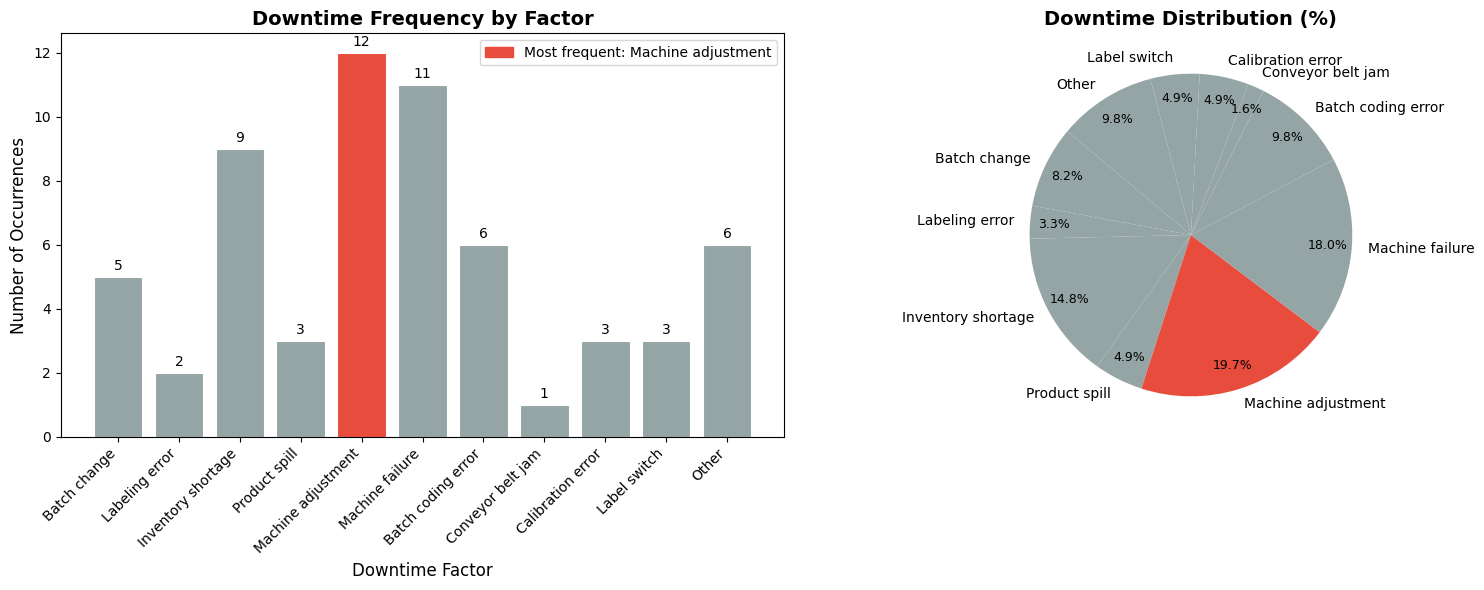

In [5]:
# improving the plot: adding a differnt color to the most frequent factor and a pie-chart with percentages: 


# Assuming you have your counts from before
counts = (df_4long.dropna(subset=['Minutes'])
                 .groupby('Factor')['Minutes']
                 .agg(count='size', total_minutes='sum')
                )

# Map column names to readable labels
factor_labels = df_33.set_index('Factor')['Description'].to_dict()
counts.index = counts.index.map(factor_labels)

# Identify the most frequent factor
most_frequent = counts['count'].idxmax()

# Colors: highlight most frequent in a distinct color
colors = ['#e74c3c' if i == most_frequent else '#95a5a6' for i in counts.index]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Bar Chart ---
bars = ax1.bar(counts.index, counts['count'], color=colors, edgecolor='white', linewidth=0.8)
ax1.set_xlabel('Downtime Factor', fontsize=12)
ax1.set_ylabel('Number of Occurrences', fontsize=12)
ax1.set_title('Downtime Frequency by Factor', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
plt.setp(ax1.get_xticklabels(), ha='right')

# Add value labels on top of bars
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
             str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)

# Add legend for highlight
highlight_patch = mpatches.Patch(color='#e74c3c', label=f'Most frequent: {most_frequent}')
ax1.legend(handles=[highlight_patch], fontsize=10)

# --- Pie Chart ---
pie_colors = ['#e74c3c' if i == most_frequent else '#95a5a6' for i in counts.index]
wedges, texts, autotexts = ax2.pie(
    counts['count'],
    labels=counts.index,
    colors=pie_colors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85
)
ax2.set_title('Downtime Distribution (%)', fontsize=14, fontweight='bold')

# Make percentage text more readable
for autotext in autotexts:
    autotext.set_fontsize(9)

plt.tight_layout()
plt.savefig('downtime_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Severity of incident - how long is the caused downtime compared to the overall machine time? 


In [7]:
#converting Start and End Time to time format: (one of the rows was not in the right format, this function checks and if necessary converts.)
import datetime

def to_time(x):
    if isinstance(x, datetime.datetime):
        return x.time()
    return x

df_31['Start Time'] = df_31['Start Time'].apply(to_time)
df_31['End Time'] = df_31['End Time'].apply(to_time)

In [8]:
# Sum all downtime minutes per batch
df_31["Total_Downtime"] = df_34.drop(columns="Batch").sum(axis=1) # I drop the column "Batch" for calculating only the rest of columns, containing downtime values.


# Calculate actual net process time (no stoppages)
df_31['Batch_minutes'] = df_31.apply(lambda row: 
    (row['End Time'].hour * 60 + row['End Time'].minute) - 
    (row['Start Time'].hour * 60 + row['Start Time'].minute) + 
    (1440 if row['End Time'] < row['Start Time'] else 0), axis=1)
df_31['Machine_Minutes'] = df_31['Batch_minutes'] - df_31['Total_Downtime']


# Total across all batches
total_batch_time = df_31['Batch_minutes'].sum()
total_net_process_time = df_31['Machine_Minutes'].sum()
total_downtime = df_31["Total_Downtime"].sum()

In [9]:
# Build summary from your long dataframe
summary = (df_4long.dropna(subset=['Minutes'])
                  .groupby('Factor')['Minutes']
                  .agg(count='size', total_minutes='sum')
                  .reset_index())

#print(summary)

In [10]:
# Build summary from your long dataframe
summary = (df_4long.dropna(subset=['Minutes'])
                  .groupby('Factor')['Minutes']
                  .agg(count='size', total_minutes='sum')
                  .reset_index())

# Map factor descriptions
summary['Description'] = summary['Factor'].map(factor_labels)

# % of total downtime (most actionable metric as we discussed)
summary['pct_downtime'] = (summary['total_minutes'] / total_downtime) * 100



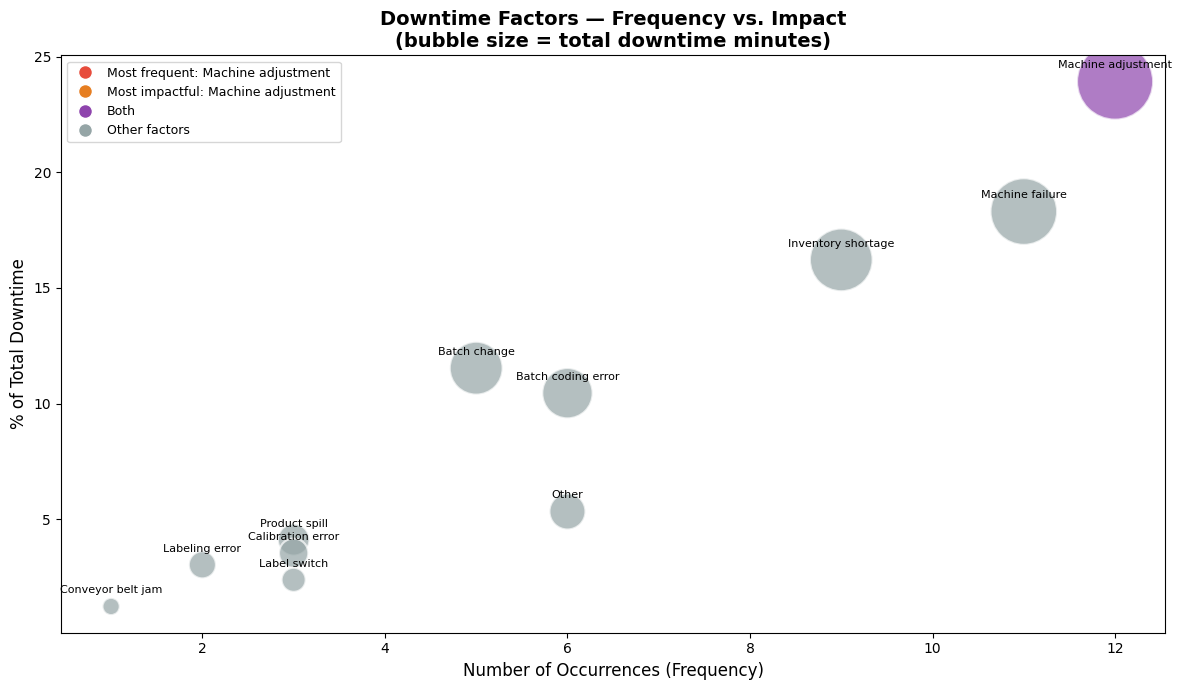

In [11]:
fig, ax = plt.subplots(figsize=(12, 7))

# Normalize bubble size
bubble_scale = 3000
sizes = (summary['total_minutes'] / summary['total_minutes'].max()) * bubble_scale

# Identify most frequent and most impactful
most_frequent = summary.loc[summary['count'].idxmax(), 'Description']
most_impactful = summary.loc[summary['total_minutes'].idxmax(), 'Description']

# Color logic
def get_color(row):
    if row['Description'] == most_frequent == most_impactful:
        return '#8e44ad'   # purple: both
    elif row['Description'] == most_frequent:
        return '#e74c3c'   # red: most frequent
    elif row['Description'] == most_impactful:
        return '#e67e22'   # orange: most impactful
    else:
        return '#95a5a6'   # grey: rest

colors = summary.apply(get_color, axis=1)

scatter = ax.scatter(summary['count'], 
                     summary['pct_downtime'],
                     s=sizes, 
                     c=colors, 
                     alpha=0.7, 
                     edgecolors='white', 
                     linewidth=1.5)

# Label each bubble
for _, row in summary.iterrows():
    ax.annotate(row['Description'],
                xy=(row['count'], row['pct_downtime']),
                ha='center', va='bottom',
                fontsize=8,
                xytext=(0, 8),
                textcoords='offset points')

ax.set_xlabel('Number of Occurrences (Frequency)', fontsize=12)
ax.set_ylabel('% of Total Downtime', fontsize=12)
ax.set_title('Downtime Factors — Frequency vs. Impact\n(bubble size = total downtime minutes)', 
             fontsize=14, fontweight='bold')

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=10, label=f'Most frequent: {most_frequent}'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e67e22', markersize=10, label=f'Most impactful: {most_impactful}'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#8e44ad', markersize=10, label='Both'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#95a5a6', markersize=10, label='Other factors'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('downtime_bubble_chart.png', dpi=150, bbox_inches='tight')
plt.show()

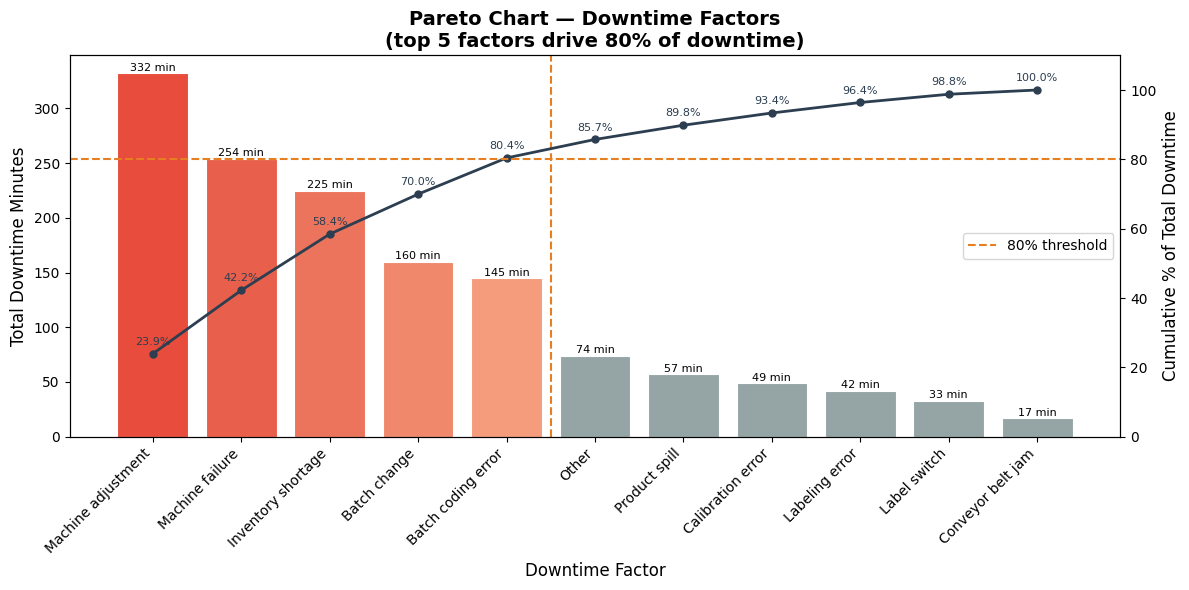

In [12]:
# Colors and more lines for a better understanding. 
# Sort by total_minutes descending for Pareto
pareto = summary.sort_values('total_minutes', ascending=False).reset_index(drop=True)

# Calculate cumulative percentage
pareto['cumulative_pct'] = pareto['total_minutes'].cumsum() / pareto['total_minutes'].sum() * 100

# Find how many factors to reach 80%
n_80 = (pareto['cumulative_pct'] <= 80).sum() + 1

fig, ax1 = plt.subplots(figsize=(12, 6))

# --- Bars: top 5 in red gradient, rest in grey ---
colors = []
red_shades = ['#e74c3c', '#e8604c', '#ec745c', '#f0886c', '#f49c7c']
for i in range(len(pareto)):
    if i < n_80:
        colors.append(red_shades[i])
    else:
        colors.append('#95a5a6')

ax1.bar(pareto['Description'], pareto['total_minutes'], color=colors, edgecolor='white', linewidth=0.8)
ax1.set_xlabel('Downtime Factor', fontsize=12)
ax1.set_ylabel('Total Downtime Minutes', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
plt.setp(ax1.get_xticklabels(), ha='right')

# Value labels on top of bars
for i, row in pareto.iterrows():
    ax1.text(i, row['total_minutes'] + 0.5, f"{int(row['total_minutes'])} min",
             ha='center', va='bottom', fontsize=8)

# --- Cumulative line ---
ax2 = ax1.twinx()
ax2.plot(pareto['Description'], pareto['cumulative_pct'],
         color='#2c3e50', marker='o', linewidth=2, markersize=5)
ax2.set_ylabel('Cumulative % of Total Downtime', fontsize=12)
ax2.set_ylim(0, 110)

# 80% reference line
ax2.axhline(y=80, color='#e67e22', linestyle='--', linewidth=1.5, label='80% threshold')
ax2.legend(fontsize=10, loc='center right')

# Cumulative % annotations
for i, row in pareto.iterrows():
    ax2.text(i, row['cumulative_pct'] + 2, f"{row['cumulative_pct']:.1f}%",
             ha='center', va='bottom', fontsize=8, color='#2c3e50')

# Vertical line separating top 5 from the rest
ax1.axvline(x=n_80 - 0.5, color='#e67e22', linestyle='--', linewidth=1.5)

ax1.set_title('Pareto Chart — Downtime Factors\n(top 5 factors drive 80% of downtime)',
              fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('downtime_pareto.png', dpi=150, bbox_inches='tight')
plt.show()